# 04 - Reliability Features, Baselines, and Threshold Tuning


> Reproducibility note: expensive training commands are shown as code or comments. For viva, these notebooks load the saved final outputs committed in the repository, so the panel can inspect the evidence without rerunning hours of training.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# Works in Colab and in a local clone. In Colab, uncomment the mount lines if needed.
try:
    from google.colab import drive  # type: ignore
    # drive.mount('/content/drive')
    COLAB_ROOT = Path('/content/drive/MyDrive/fake-news-rl-fusion')
    PROJECT_ROOT = COLAB_ROOT if COLAB_ROOT.exists() else Path.cwd().resolve().parent
except Exception:
    PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

print('PROJECT_ROOT =', PROJECT_ROOT)

def read_json(relative_path):
    with open(PROJECT_ROOT / relative_path, 'r', encoding='utf-8') as f:
        return json.load(f)

def read_csv(relative_path):
    return pd.read_csv(PROJECT_ROOT / relative_path)

def show_metrics(metrics, keys=('macro_f1', 'accuracy', 'roc_auc', 'balanced_accuracy')):
    rows = []
    for key in keys:
        if key in metrics:
            rows.append({'metric': key, 'value': metrics[key]})
    display(pd.DataFrame(rows))

PROJECT_ROOT = C:\Users\acer\Documents\GitHub\fake-news-rl-fusion


## Purpose
This notebook shows the baseline comparison required for defending that RL fusion is evaluated against strong alternatives: image-only, text-only, equal fusion, confidence-weighted fusion, reliability-weighted fusion, and supervised MLP fusion.

,source,split,method,macro_f1,accuracy,roc_auc
0,rl,test,rl_full_state,0.867604,0.867725,0.932894
1,baseline,test,equal_fusion,0.867333,0.867460,0.932542
2,baseline,test,confidence_weighted_fusion,0.867333,0.867460,0.933996
3,ablation,test,rl_full_reliability_state,0.867333,0.867460,0.932643
4,baseline,test,reliability_weighted_fusion,0.861206,0.861376,0.932866
5,ablation,test,rl_prediction_confidence,0.858994,0.858995,0.918426
6,ablation,test,rl_probabilities_only,0.852315,0.852381,0.920512
7,supervised_fusion,test,supervised_mlp_fusion,0.849998,0.850000,0.929069
8,baseline,test,text_only,0.838769,0.838889,0.912095
9,baseline,test,image_only,0.776928,0.779101,0.857216


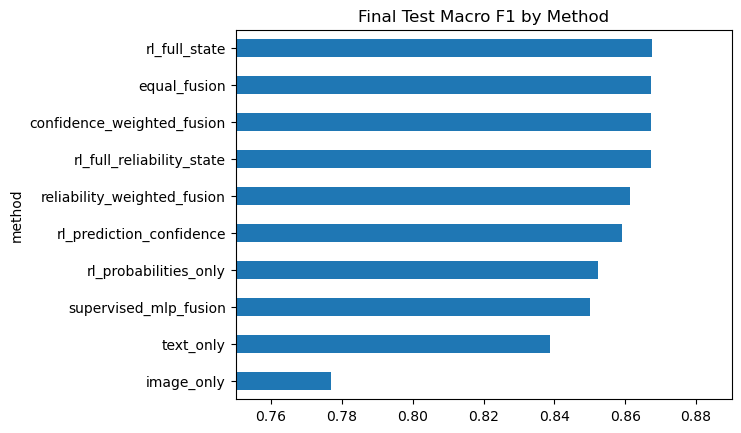

In [2]:
method_table = read_csv('outputs/tables/final_method_comparison.csv')
test_methods = method_table[method_table['split'].eq('test')].sort_values('macro_f1', ascending=False)
display(test_methods)
ax = test_methods.plot.barh(x='method', y='macro_f1', legend=False, title='Final Test Macro F1 by Method')
ax.invert_yaxis()
ax.set_xlim(0.75, 0.89)
plt.show()

In [3]:
thresholds = read_csv('outputs/metrics/final_threshold_tuning_summary.csv')
display(thresholds.sort_values('test_macro_f1_tuned', ascending=False))
print('Best tuned baseline:', thresholds[thresholds['source'].eq('baseline')].sort_values('test_macro_f1_tuned', ascending=False).iloc[0][['method','test_macro_f1_tuned']].to_dict())
print('RL tuned:', thresholds[thresholds['method'].eq('rl_adaptive_fusion')].iloc[0][['method','test_macro_f1_tuned','selected_threshold']].to_dict())

,method,source,selected_threshold,validation_macro_f1_at_selected_threshold,test_macro_f1_at_0_5,test_macro_f1_tuned,test_accuracy_tuned,test_roc_auc
5,rl_adaptive_fusion,rl,0.490,0.870406,0.867604,0.868455,0.868519,0.932894
2,equal_fusion,baseline,0.485,0.869895,0.867333,0.867142,0.867196,0.932542
3,confidence_weighted_fusion,baseline,0.480,0.870421,0.867333,0.867139,0.867196,0.933996
4,reliability_weighted_fusion,baseline,0.480,0.869091,0.861206,0.863947,0.864021,0.932866
6,supervised_mlp_fusion,supervised_fusion,0.635,0.859920,0.849998,0.850993,0.851058,0.929069
1,text_only,baseline,0.480,0.849366,0.838769,0.838529,0.838624,0.912095
0,image_only,baseline,0.425,0.798866,0.776928,0.779371,0.779894,0.857216


Best tuned baseline: {'method': 'equal_fusion', 'test_macro_f1_tuned': 0.867142060170456}
RL tuned: {'method': 'rl_adaptive_fusion', 'test_macro_f1_tuned': 0.8684550955427615, 'selected_threshold': 0.4899999999999999}


In [4]:
reliability = read_json('outputs/metrics/final_reliability_stats.json')
display(pd.DataFrame(reliability.get('splits', {})).T)
print('Image normalization:', reliability.get('image_normalization'))

,image_quality_mean,output_path,rows,text_quality_mean
test,0.638617,data/final_modality_outputs/test_outputs.csv,3780,0.753495
train,0.633675,data/final_modality_outputs/train_outputs.csv,18893,0.752299
validation,0.633698,data/final_modality_outputs/validation_outputs...,3798,0.751357


Image normalization: {'blur': {'high': 4224.834082031237, 'low': 68.28135681152344}, 'contrast': {'high': 81.56913452148437, 'low': 32.42022705078125}, 'entropy': {'high': 7.812583880435012, 'low': 4.384276363311864}}


In [5]:
# Reproduction commands:
# %cd /content/drive/MyDrive/fake-news-rl-fusion
# !python scripts/build_reliability_outputs.py --config configs/final_reliability.yaml
# !python scripts/run_baselines.py --config configs/final_baselines.yaml
# !python scripts/train_supervised_fusion.py --config configs/final_supervised_fusion.yaml
# !python scripts/tune_thresholds.py --config configs/final_threshold_tuning.yaml

## Viva Note
The gain over fixed fusion is small, so the correct claim is not dramatic accuracy improvement. The defensible claim is: RL gives competitive/slightly better performance while also producing adaptive sample-level fusion actions and interpretable weights.